# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import gc
import os
import sys
import random
import wandb
sys.path.append('../utils')
sys.path.append('../data_utils')
sys.path.append('../models')
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item, ABCdataset, get_vdb_data_loader
import mesh_tools as mt
import fvdb_utils as fu
import model as fvdbModel
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure

# Args

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm'
sdf_nmc_dir = '/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC'

# Load Dataset

In [4]:
with open('../data_utils/abc_watertight_train.txt', 'r') as f:
    train_set_names = [e[:-1] for e in f.readlines()]
train_set_names = train_set_names[:150]

In [5]:
random.shuffle(train_set_names)
train_size = int(0.6 * len(train_set_names))
test_size = int(0.2 * len(train_set_names))
val_size = len(train_set_names) - train_size - test_size
train_names = train_set_names[:train_size]
val_names = train_set_names[train_size:train_size + val_size]
test_names = train_set_names[train_size + val_size:]

train_dataset = ABCdataset(sdf_nmc_dir, train_names)
val_dataset = ABCdataset(sdf_nmc_dir, val_names)
test_dataset = ABCdataset(sdf_nmc_dir, test_names, mode='test')

print(f'Number of samples in the dataset: {len(train_set_names)}')
print(f'Number of samples in the train set: {len(train_dataset)}')
print(f'Number of samples in the test set: {len(test_dataset)}')
print(f'Number of samples in the validation set: {len(val_dataset)}')

100%|██████████| 30/30 [00:00<00:00, 21586.74it/s]

Number of samples in the dataset: 150
Number of samples in the train set: 90
Number of samples in the test set: 30
Number of samples in the validation set: 30


In [6]:
# %reload_ext autoreload
train_data_loader = get_vdb_data_loader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_data_loader = get_vdb_data_loader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_data_loader = get_vdb_data_loader(test_dataset, batch_size=1, shuffle=False, num_workers=0, mode='test')

# Train Model

`Position Encoding`

In [7]:
def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))

In [8]:
# wandb.init(project="SSU", entity="sp_kumar", name="SSU_NMC_VAE_1", config={
#     "batch_size": 1,
#     "learning_rate": 1e-3,
#     "epochs": 5,
#     "positional_encoding_dim": 10,
#     "model": "CNN_VAE",
#     "dataset": "SSU_NMC",
#     "dataset_size": len(train_set_names),
#     "dataset_split": {
#         "train": len(train_dataset),
#         "val": len(val_dataset),
#         "test": len(test_dataset)
#     },
#     "loss_function": "VAE loss",
#     "optimizer": "Adam",
#     "device": device
# })

`Other Param`

In [9]:
latent_ijk = torch.tensor([[0, 0, 0]], dtype=torch.int32, device=device)
latent_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(latent_ijk))

In [9]:
# # Use test_vdb_tensor as input
# vdb_tensor = test_vdb_tensor
# # Assume vdb_tensor is a fvnn.VDBTensor
# linear = fvnn.Linear(1, 128).to(device)  # Linear layer to match the input/output channels
# linear(vdb_tensor)  # Apply linear layer to the features
# # Apply linear layer to the features
# vdb_tensor = fvnn.VDBTensor(
#     vdb_tensor.grid,
#     vdb_tensor.grid.jagged_like(linear(vdb_tensor).jdata)
# )

# # Define a SparseConv3d layer with matching in/out channels
# sparse_conv = fvnn.SparseConv3d(128, 1, kernel_size=3, stride=1).to(device)
# out = sparse_conv(vdb_tensor)

In [80]:
class CNN_VAE(nn.Module):
    def __init__(self, in_channels=3, features=32, latent_dim=256, out_channels=1, dropout=0.05):
        super(CNN_VAE, self).__init__()
        self.activation = fvnn.SiLU(inplace=True)
        # Encoder
        # 32
        self.en1 = fvnn.SparseConv3d(in_channels, features, kernel_size=3, stride=1)
        self.en1_drop = fvnn.Dropout(dropout)
        self.en1_batchnorm = fvnn.BatchNorm(features)
        self.en1_act = self.activation
        # 16
        self.en2 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2)
        self.en2_drop = fvnn.Dropout(dropout)
        self.en2_batchnorm = fvnn.BatchNorm(features)
        self.en2_act = self.activation
        # 8
        self.en3 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2)
        self.en3_drop = fvnn.Dropout(dropout)
        self.en3_batchnorm = fvnn.BatchNorm(features)
        self.en3_act = self.activation
        # 4
        self.en4 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2)
        self.en4_drop = fvnn.Dropout(dropout)
        self.en4_batchnorm = fvnn.BatchNorm(features)
        self.en4_act = self.activation
        # 2
        self.en5 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2)
        self.en5_drop = fvnn.Dropout(dropout)
        self.en5_batchnorm = fvnn.BatchNorm(features)
        self.en5_act = self.activation
        # 1
        self.en6 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2)
        self.en6_drop = fvnn.Dropout(dropout)
        self.en6_batchnorm = fvnn.BatchNorm(features)
        self.en6_act = self.activation
        
        # Latent layers
        # self.fc_mu = nn.Linear(features, latent_dim)
        # self.fc_logvar = nn.Linear(features, latent_dim)
        # self.fc_decode = nn.Linear(latent_dim, features)
        self.mu = fvnn.SparseConv3d(features, latent_dim, kernel_size=1, stride=1)
        self.logvar = fvnn.SparseConv3d(features, latent_dim, kernel_size=1, stride=1)
        # self.sparse_decode = fvnn.SparseConv3d(latent_dim, features, kernel_size=3, stride=1)

        # Decoder
        # 2
        self.dec_1 = fvnn.SparseConv3d(latent_dim, features, kernel_size=3, stride=2, transposed=True)
        self.dec_1_drop = fvnn.Dropout(dropout)
        self.dec_1_batchnorm = fvnn.BatchNorm(features)
        self.dec_1_act = self.activation
        # 4
        self.dec_2 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2, transposed=True)
        self.dec_2_drop = fvnn.Dropout(dropout)
        self.dec_2_batchnorm = fvnn.BatchNorm(features)
        self.dec_2_act = self.activation
        # 8
        self.dec_3 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2, transposed=True)
        self.dec_3_drop = fvnn.Dropout(dropout)
        self.dec_3_batchnorm = fvnn.BatchNorm(features)
        self.dec_3_act = self.activation
        # 16
        self.dec_4 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2, transposed=True)
        self.dec_4_drop = fvnn.Dropout(dropout)
        self.dec_4_batchnorm = fvnn.BatchNorm(features)
        self.dec_4_act = self.activation
        # 32
        self.dec_5 = fvnn.SparseConv3d(features, features, kernel_size=3, stride=2, transposed=True)
        self.dec_5_drop = fvnn.Dropout(dropout)
        self.dec_5_batchnorm = fvnn.BatchNorm(features)
        self.dec_5_act = self.activation
        # 64
        self.dec_6 = fvnn.SparseConv3d(features, out_channels, kernel_size=3, stride=1)

    def reparameterize(self, mu_vdb, logvar_vdb, grid):
        # Reparameterization trick
        mu = mu_vdb.jdata
        logvar = logvar_vdb.jdata

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        values =  mu + eps * std

        latent_vdb = fvnn.VDBTensor(grid, grid.jagged_like(values))
        return latent_vdb, mu, logvar

    def forward(self, x, grid, grid2):
        #32
        x_en1 = self.en1_act(self.en1_batchnorm(self.en1_drop(self.en1(x))))
        # 16
        x_en2 = self.en2_act(self.en2_batchnorm(self.en2_drop(self.en2(x_en1))))
        # 8
        x_en3 = self.en3_act(self.en3_batchnorm(self.en3_drop(self.en3(x_en2))))
        # 4
        x_en4 = self.en4_act(self.en4_batchnorm(self.en4_drop(self.en4(x_en3))))
        # 2
        x_en5 = self.en5_act(self.en5_batchnorm(self.en5_drop(self.en5(x_en4))))
        # 1
        # print(x_en5.grid.ijk.jdata)
        x_en6 = self.en6_act(self.en6_drop(self.en5(x_en5)))  # Last layer, no downsampling
        # 1
        
        # latent representation
        x_mu = self.mu(x_en6)
        x_logvar = self.logvar(x_en6)
    
        z, mu, logvar = self.reparameterize(x_mu, x_logvar, x_en6.grid)
        
        # decode
        # 1
        x_dec1 = self.dec_1_act(self.dec_1_batchnorm(self.dec_1_drop(self.dec_1(z, out_grid=x_en6.grid))))
        # 2
        x_dec2 = self.dec_2_act(self.dec_2_batchnorm(self.dec_2_drop(self.dec_2(x_dec1, out_grid=x_en5.grid))))
        # 4
        x_dec3 = self.dec_3_act(self.dec_3_batchnorm(self.dec_3_drop(self.dec_3(x_dec2, out_grid=x_en4.grid))))
        # 8
        x_dec4 = self.dec_4_act(self.dec_4_batchnorm(self.dec_4_drop(self.dec_4(x_dec3, out_grid=x_en3.grid))))
        # 16
        x_dec5 = self.dec_5_act(self.dec_5_batchnorm(self.dec_5_drop(self.dec_5(x_dec4, out_grid=x_en2.grid))))
        # 32
        x_dec6 = self.dec_6(x_dec5, out_grid=x_en1.grid)  # No activation on the last layer
        # 64
        return x_dec6, mu, logvar

In [81]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss (e.g., MSE)
    recon_loss = (recon_x.jdata - x.jdata).pow(2).mean()  # Mean Squared Error
    # recon_loss = nn.MSELoss()(recon_x.jdata, x.jdata)
    # KL divergence
    logvar = torch.clamp(logvar, min=-10, max=10)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # print(kld.item())
    # print(recon_loss.item(), kld.item())
    return recon_loss + 1e-3 * kld  # Adjust KLD weight as needed

In [82]:
pos_enc_dim = 10
model = CNN_VAE(in_channels=pos_enc_dim+1, features=128, out_channels=1)
model = model.to(device)

In [83]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-5)
criterion = nn.MSELoss()

In [84]:
small_vdb, large_vdb = train_dataset[0]
model.train()
b = model(positional_encoding(small_vdb, pos_enc_dim).to(device), latent_grid, large_vdb.grid)
# b[0].grid.ijk.jdata.shape, large_vdb.grid.ijk.jdata.shape, b[1], b[2]

`Training`

In [85]:
def train(model, train_data_loader, val_data_loader, optimizer, criterion, epochs, device):
    history = []
    # saliency_labels = ['sdf'] + [f'pos_enc_{i}' for i in range(pos_enc_dim)]
    # saliency_feature = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        Loss = []
        
        model.train()
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            # small_vdb.jdata.requires_grad_()
            large_vdb = large_vdb.to(device)
            
            optimizer.zero_grad()
            recon, mu, logvar = model(small_vdb, latent_grid, large_vdb.grid)
            # loss = vae_loss(recon, large_vdb, mu, logvar)
            loss = vae_loss(recon, small_vdb, mu, logvar)

            # recon = model(small_vdb, latent_grid, large_vdb.grid)
            # loss = criterion(recon.jdata, large_vdb.jdata)


            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

        # save saliency 
        # saliency_feature.append(small_vdb.jdata.grad.abs().mean(dim=0).cpu().numpy())
        
        avg_loss = epoch_loss / len(train_data_loader)
        Loss.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        # Validation
        with torch.no_grad():
            
            model.eval()
            val_loss = 0
            
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                small_vdb = positional_encoding(small_vdb.to(device), pos_enc_dim)
                large_vdb = large_vdb.to(device)

                recon, mu, logvar = model(small_vdb, latent_grid, large_vdb.grid)
                # loss = vae_loss(recon, large_vdb, mu, logvar)
                loss = vae_loss(recon, small_vdb, mu, logvar)

                # recon = model(small_vdb, latent_grid, large_vdb.grid)
                # loss = criterion(recon.jdata, large_vdb.jdata) 
                
                val_loss += loss.item()
            
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')
        
        Loss.append(avg_val_loss)
        # wandb.log({
        # "train_loss": avg_loss,
        # "val_loss": avg_val_loss,
        # "epoch": epoch})

        history.append(Loss)

    return history

In [86]:
gc.collect()
torch.cuda.empty_cache()

In [87]:
history = train(model, 
                train_data_loader, 
                val_data_loader, 
                optimizer, 
                criterion, 
                epochs=10, 
                device=device)

Epoch 1/10: 100%|██████████| 90/90 [00:10<00:00,  8.55it/s]


Epoch 1/10, Loss: 0.8861


Validation: 100%|██████████| 30/30 [00:02<00:00, 10.77it/s]


Validation Loss: 0.7658


Epoch 2/10: 100%|██████████| 90/90 [00:09<00:00,  9.43it/s]


...

Validation Loss: 0.6982


Epoch 10/10: 100%|██████████| 90/90 [00:08<00:00, 10.92it/s]


Epoch 10/10, Loss: 0.6949


Validation: 100%|██████████| 30/30 [00:01<00:00, 20.82it/s]

Validation Loss: 0.6997


In [88]:
# wandb.finish()

`Plot history`

In [89]:
history = np.clip(history, 0, 10)

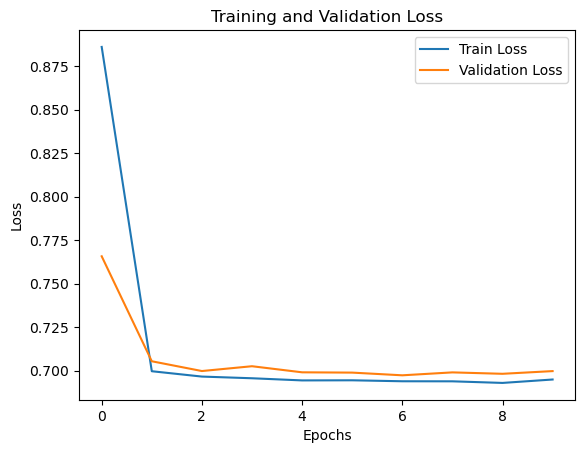

In [90]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

`display test sample`

In [91]:
# idx = random.randint(0, len(test_dataset)-1)
idx=0
small_sdf, large_sdf, mask, input, actual = test_dataset[idx]
input = positional_encoding(input, pos_enc_dim).to(device)
actual = actual.to(device)

# large grid from small VDBTensor
small_vdb, large_grid = fu.sdf_to_vdb(small_sdf, 
                                      None, 
                                      mask = mask, 
                                      size=33, mode='test')

pred, _, _ = model(input, latent_grid, large_grid)

In [92]:
# input_feature = input.jdata.grad.abs().mean(dim=0)
# labels = ['feature'] + [f'pos_enc_{i}' for i in range(pos_enc_dim)]

In [93]:
v, f = fu.vdb_marching_cubes(small_vdb)
plot(v,f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(2.1457672…

In [94]:
v, f = fu.vdb_marching_cubes(pred)
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.007269…

In [95]:
v, f = fu.vdb_marching_cubes(actual)
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(2.1904706…

In [32]:
input.grid

(32768, 3)
[[0 0 0]]


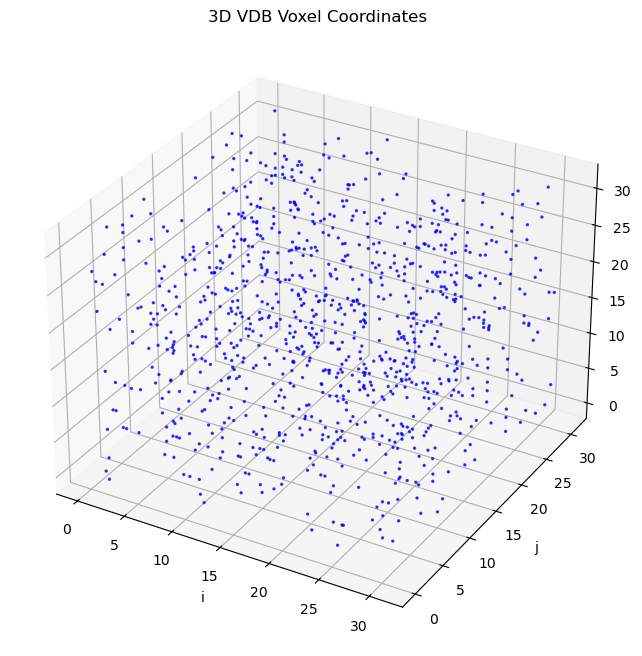

torch.Size([2422, 3])


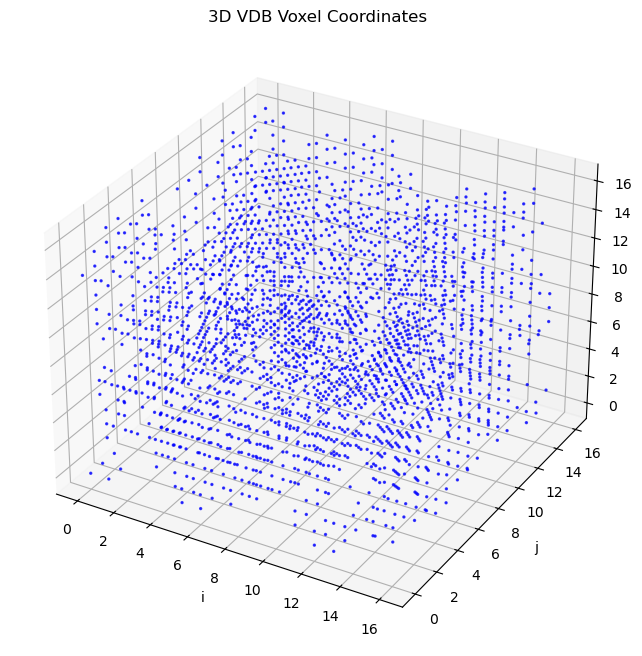

torch.Size([718, 3])


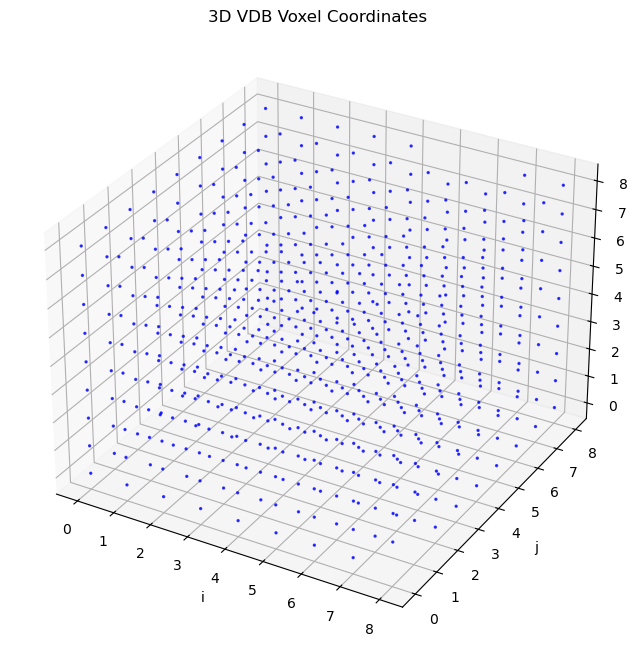

torch.Size([125, 3])


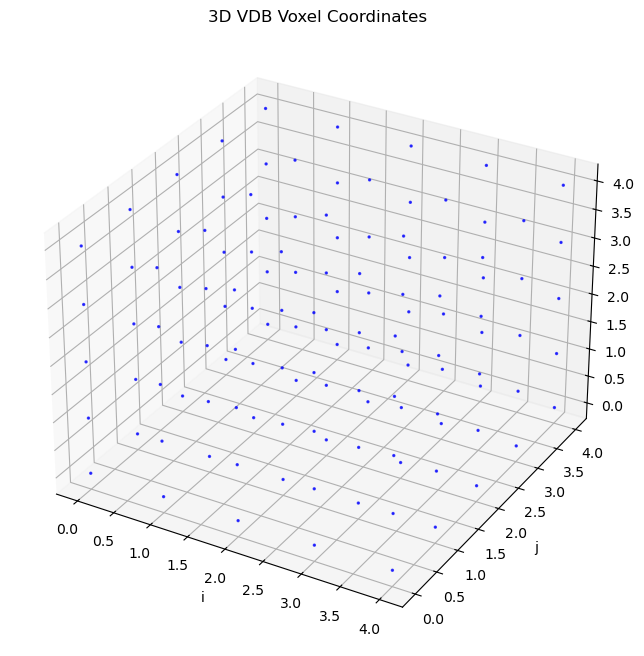

torch.Size([27, 3])


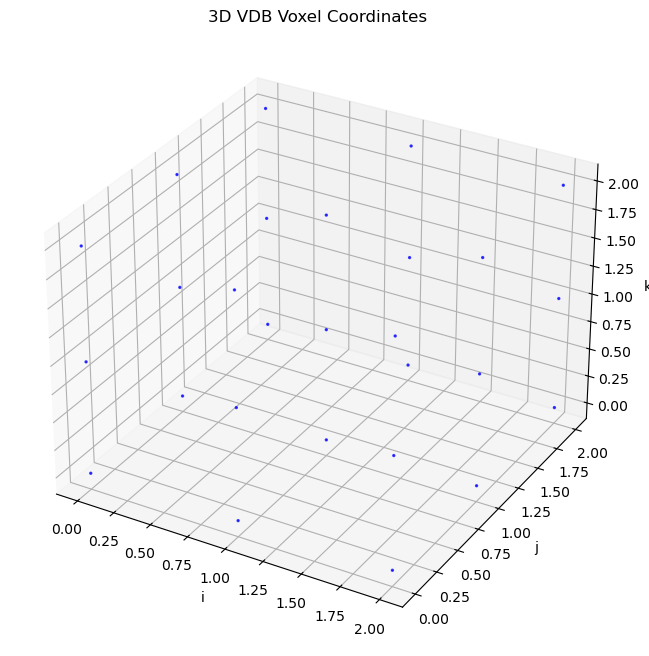

torch.Size([8, 3])


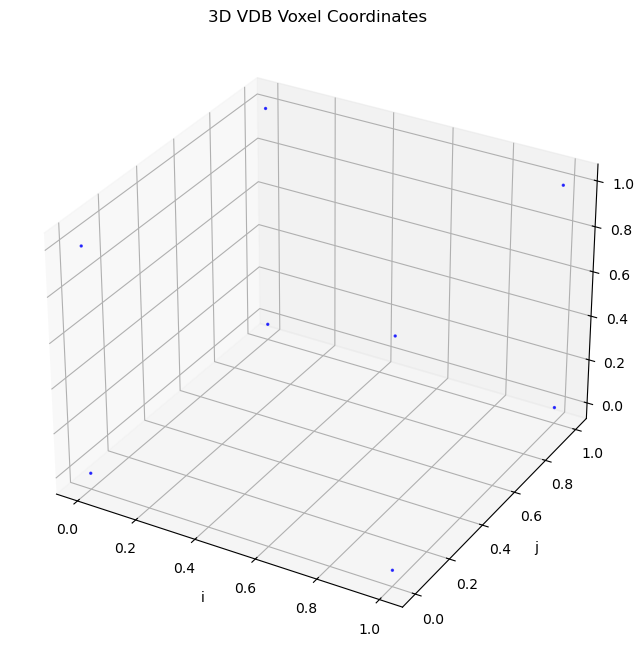

torch.Size([8, 3])


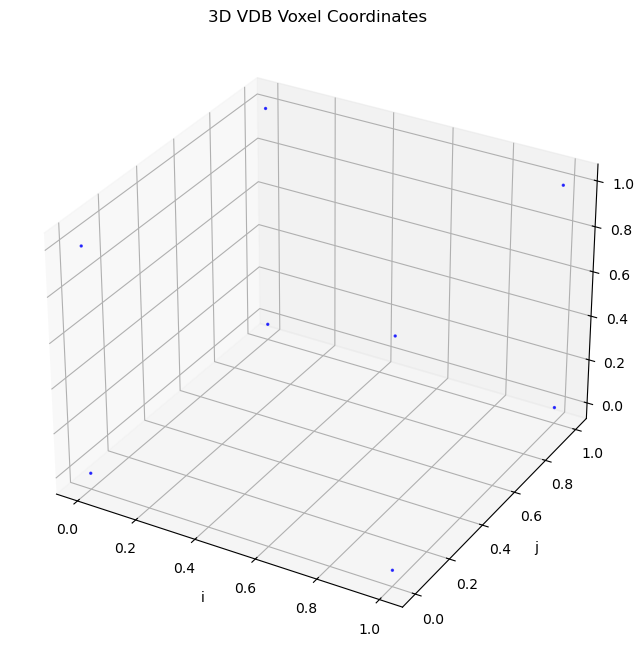

tensor([[0, 0, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 1],
        [1, 0, 0],
        [1, 0, 1],
        [1, 1, 0],
        [1, 1, 1]], device='cuda:0', dtype=torch.int32)


In [13]:
linear = fvnn.Linear(11, 128).to(device)
# linear = linear.to(device)
# linear to grid
# create random ijk coordinates of 32 * 32 * 32
shape = (32, 32, 32)
n = 1000
all_indices = np.array(np.meshgrid(
    np.arange(shape[0]),
    np.arange(shape[1]),
    np.arange(shape[2]),
    indexing='ij'
)).reshape(3, -1).T
print(all_indices.shape)
# Randomly choose n unique indices
chosen_indices = all_indices[np.random.choice(all_indices.shape[0], n, replace=False)]
# print(chosen_indices)
test_ijk = torch.tensor(chosen_indices, dtype=torch.int32, device=device)
test_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(test_ijk), 
                                 voxel_sizes=1.0, 
                                 origins=(0, 0, 0))
tets_values = torch.randn(n, 1, device=device)
test_vdb_tensor = fvnn.VDBTensor(test_grid, fvdb.JaggedTensor(tets_values))

shape = (16, 16, 16)
all_indices = np.array(np.meshgrid(
    np.arange(shape[0]),
    np.arange(shape[1]),
    np.arange(shape[2]),
    indexing='ij'
)).reshape(3, -1).T  # shape: (512, 3)

# 2. Convert to torch tensor
ijk = torch.tensor(all_indices, dtype=torch.int32, device=device)

# 3. Create grid
test_grid2 = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk))


shape = (1, 1, 1)
all_indices = np.array(np.meshgrid(
    np.arange(shape[0]),
    np.arange(shape[1]),
    np.arange(shape[2]),
    indexing='ij'
)).reshape(3, -1).T  # shape: (512, 3)
print(all_indices)
# 2. Convert to torch tensor
ijk = torch.tensor(all_indices, dtype=torch.int32, device=device)

# 3. Create grid
test_grid3 = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk))


# linear_grid = linear(input)
conv = fvnn.SparseConv3d(1, 1, kernel_size=3, stride=2).to(device)
# print(x.grid.ijk.jdata.shape)
# square root
ijk = test_vdb_tensor.grid.ijk.jdata.cpu().numpy()  # shape: (N, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ijk[:, 0], ijk[:, 1], ijk[:, 2], s=2, c='b', alpha=0.7)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('k')
plt.title('3D VDB Voxel Coordinates')
plt.show()
x = conv(test_vdb_tensor)
print(x.grid.ijk.jdata.shape)
# square root
ijk = x.grid.ijk.jdata.cpu().numpy()  # shape: (N, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ijk[:, 0], ijk[:, 1], ijk[:, 2], s=2, c='b', alpha=0.7)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('k')
plt.title('3D VDB Voxel Coordinates')
plt.show()

x = conv(x)
print(x.grid.ijk.jdata.shape)
# plot 3d ijk coordinates
ijk = x.grid.ijk.jdata.cpu().numpy()  # shape: (N, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ijk[:, 0], ijk[:, 1], ijk[:, 2], s=2, c='b', alpha=0.7)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('k')
plt.title('3D VDB Voxel Coordinates')
plt.show()
# print(ijk.shape[0]**(1/3))

x = conv(x)
print(x.grid.ijk.jdata.shape)
ijk = x.grid.ijk.jdata.cpu().numpy()  # shape: (N, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ijk[:, 0], ijk[:, 1], ijk[:, 2], s=2, c='b', alpha=0.7)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('k')
plt.title('3D VDB Voxel Coordinates')
plt.show()
x = conv(x)
print(x.grid.ijk.jdata.shape)
ijk = x.grid.ijk.jdata.cpu().numpy()  # shape: (N, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ijk[:, 0], ijk[:, 1], ijk[:, 2], s=2, c='b', alpha=0.7)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('k')
plt.title('3D VDB Voxel Coordinates')
plt.show()
x = conv(x)
print(x.grid.ijk.jdata.shape)
ijk = x.grid.ijk.jdata.cpu().numpy()  # shape: (N, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ijk[:, 0], ijk[:, 1], ijk[:, 2], s=2, c='b', alpha=0.7)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('k')
plt.title('3D VDB Voxel Coordinates')
plt.show()

x = conv(x)
print(x.grid.ijk.jdata.shape)
ijk = x.grid.ijk.jdata.cpu().numpy()  # shape: (N, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ijk[:, 0], ijk[:, 1], ijk[:, 2], s=2, c='b', alpha=0.7)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('k')
plt.title('3D VDB Voxel Coordinates')
plt.show()
print(x.grid.ijk.jdata)

In [ ]:
pred.grid.ijk.jdata.shape

torch.Size([76630, 3])

In [62]:
input.jdata.shape, input.grid.ijk.jdata

(torch.Size([4893, 11]),
 tensor([[-16,  -6,  -6],
         [-16,  -6,  -5],
         [-16,  -6,  -4],
         ...,
         [ 16,   6,   2],
         [ 16,   6,   3],
         [ 16,   6,   4]], device='cuda:0', dtype=torch.int32))